## Two-stage adaptive receiver

The signal is now divided into two equal temporal bins. Since the total mean
photon number is $\bar n = |\alpha|^2$, the coherent amplitude in each bin is

$$
\alpha_{\mathrm{bin}} = \frac{\alpha}{\sqrt{2}}.
$$

A displacement $\beta_1$ is applied to the first bin, followed by an on/off
photon measurement.

The displacement applied to the second bin depends on the first measurement:

- after no click: use $\beta_{2,\mathrm{no}}$,
- after a click: use $\beta_{2,\mathrm{click}}$.

This is the first adaptive receiver, since the measurement setting used later
depends on an earlier detector outcome.

There are four possible measurement histories,

$$
00,\quad 01,\quad 10,\quad 11,
$$

where 0 denotes no click and 1 denotes a click.

For each history, the receiver compares how likely that history was under
$|+\alpha\rangle$ and $|-\alpha\rangle$ and chooses the more likely state.

### Optimizing the first displacement in a multi-stage receiver

In a multi-stage receiver, the best first displacement $\beta_1$ is not necessarily the one that gives the lowest error after the first measurement alone.

After applying $\beta_1$, there are two possible branches,

$$
\beta_1
\rightarrow
\begin{cases}
\text{no click} \rightarrow \text{updated posterior},\\
\text{click} \rightarrow \text{updated posterior}.
\end{cases}
$$

Each branch is then followed by another measurement with its own optimized displacement.

Therefore, when choosing $\beta_1$, we care about:

- how likely each branch is,
- how uncertain each branch is,
- and how much the next measurement can improve each branch.

The first displacement should therefore be chosen to minimize the final error after all stages,

$$
P_{\mathrm{final}}(\beta_1)
=
P(0)\,P_{\mathrm{final}|0}
+
P(1)\,P_{\mathrm{final}|1}.
$$

A value of $\beta_1$ that is slightly worse if we stop after stage 1 can still give a lower final error if it produces branches that are easier to distinguish in stage 2.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from dolinar_receiver.receivers import (
    no_click_probability,
    optimized_displacement,
)

In [5]:
#First , we define a function that computes the probability of a click/no-click outcome after displacement.
def detector_outcome_probability(signal, beta, clicked):
    #Probability of a click/no-click outcome after displacement

    displaced_amplitude = signal + beta
    p_no_click = no_click_probability(displaced_amplitude)

    if clicked:
        return 1 - p_no_click

    return p_no_click

In [6]:
#Then make the actual two-stage receiver
def two_stage_error(
    nbar,
    beta_first,
    beta_after_no_click,
    beta_after_click
):
    #Exact error probability of a two-stage adaptive receiver

    alpha_bin = np.sqrt(nbar / 2)

    total_error = 0.0

    # First measurement: click or no click
    for first_click in [False, True]:

        if first_click:
            beta_second = beta_after_click
        else:
            beta_second = beta_after_no_click

        # Second measurement: click or no click
        for second_click in [False, True]:

            # Probability of this history if +alpha was sent
            p_plus = (
                detector_outcome_probability(
                    +alpha_bin,
                    beta_first,
                    first_click
                )
                *
                detector_outcome_probability(
                    +alpha_bin,
                    beta_second,
                    second_click
                )
            )

            # Probability of the same history if -alpha was sent
            p_minus = (
                detector_outcome_probability(
                    -alpha_bin,
                    beta_first,
                    first_click
                )
                *
                detector_outcome_probability(
                    -alpha_bin,
                    beta_second,
                    second_click
                )
            )

            # Equal priors and optimal final guess
            total_error += min(
                0.5 * p_plus,
                0.5 * p_minus
            )

    return total_error

In [7]:
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

In [8]:
#We do basic optimization of the three displacements of the two-stage receiver using differential evolution.
def optimize_two_stage(nbar):
    #Globally optimize the three displacements of the two-stage receiver

    result = differential_evolution(
        lambda betas: two_stage_error(
            nbar,
            betas[0],
            betas[1],
            betas[2]
        ),
        bounds=[
            (-3, 3),
            (-3, 3),
            (-3, 3)
        ],
        seed=1234,
        polish=True
    )

    return result.x, result.fun

In [9]:
nbar_test = 0.5

betas, error = optimize_two_stage(nbar_test)

print("beta first:", betas[0])
print("beta after no click:", betas[1])
print("beta after click:", betas[2])
print("Two-stage error:", error)

beta first: -0.754771192291218
beta after no click: -0.5752128434105024
beta after click: 0.5283424296418386
Two-stage error: 0.046468001815371696


In [10]:
_, fixed_error = optimized_displacement(nbar_test)

print("Optimized fixed error:", fixed_error)
print("Optimized two-stage error:", error)

Optimized fixed error: 0.054361438961019116
Optimized two-stage error: 0.046468001815371696


In [11]:
from dolinar_receiver.receivers import (
    helstrom_error,
    optimized_displacement,
)

In [12]:
#We can now compute the error probabilities of the two-stage adaptive receiver and the optimized fixed displacement receiver for a range of nbar values.
nbar_values = np.linspace(0.02, 2, 50)

adaptive_errors = []
fixed_errors = []
optimized_betas = []

for i, n in enumerate(nbar_values):

    betas, adaptive_error = optimize_two_stage(n)
    _, fixed_error = optimized_displacement(n)

    optimized_betas.append(betas)
    adaptive_errors.append(adaptive_error)
    fixed_errors.append(fixed_error)

    print(
        f"{i + 1}/{len(nbar_values)}: "
        f"nbar={n:.3f}, error={adaptive_error:.5f}"
    )

adaptive_errors = np.array(adaptive_errors)
fixed_errors = np.array(fixed_errors)
optimized_betas = np.array(optimized_betas)

1/50: nbar=0.020, error=0.37267
2/50: nbar=0.060, error=0.28564
3/50: nbar=0.101, error=0.23159
4/50: nbar=0.141, error=0.19191
5/50: nbar=0.182, error=0.16095
6/50: nbar=0.222, error=0.13602
7/50: nbar=0.262, error=0.11553
8/50: nbar=0.303, error=0.09849
9/50: nbar=0.343, error=0.08419
10/50: nbar=0.384, error=0.07210
11/50: nbar=0.424, error=0.06184
12/50: nbar=0.464, error=0.05309
13/50: nbar=0.505, error=0.04562
14/50: nbar=0.545, error=0.03923
15/50: nbar=0.586, error=0.03374
16/50: nbar=0.626, error=0.02903
17/50: nbar=0.667, error=0.02498
18/50: nbar=0.707, error=0.02149
19/50: nbar=0.747, error=0.01849
20/50: nbar=0.788, error=0.01591
21/50: nbar=0.828, error=0.01369
22/50: nbar=0.869, error=0.01178
23/50: nbar=0.909, error=0.01013
24/50: nbar=0.949, error=0.00871
25/50: nbar=0.990, error=0.00749
26/50: nbar=1.030, error=0.00643
27/50: nbar=1.071, error=0.00553
28/50: nbar=1.111, error=0.00559
29/50: nbar=1.151, error=0.00408
30/50: nbar=1.192, error=0.00350
31/50: nbar=1.232, 

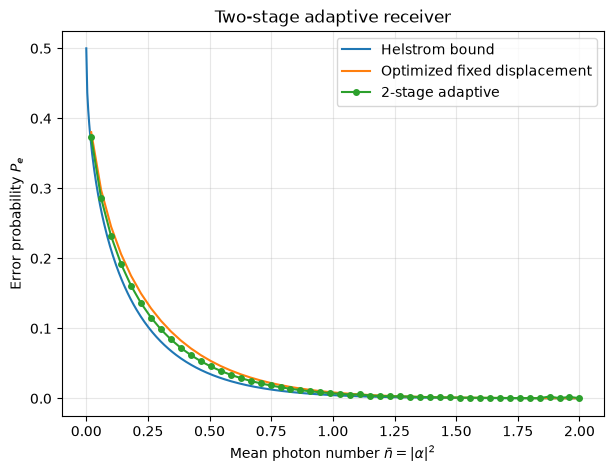

In [13]:
#we plot the error probabilities of the two-stage adaptive receiver and the optimized fixed displacement receiver, along with the Helstrom bound.
nbar_smooth = np.linspace(0, 2, 500)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    nbar_smooth,
    helstrom_error(nbar_smooth),
    label="Helstrom bound"
)

ax.plot(
    nbar_values,
    fixed_errors,
    label="Optimized fixed displacement"
)

ax.plot(
    nbar_values,
    adaptive_errors,
    marker="o",
    markersize=4,
    label="2-stage adaptive"
)

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Two-stage adaptive receiver")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

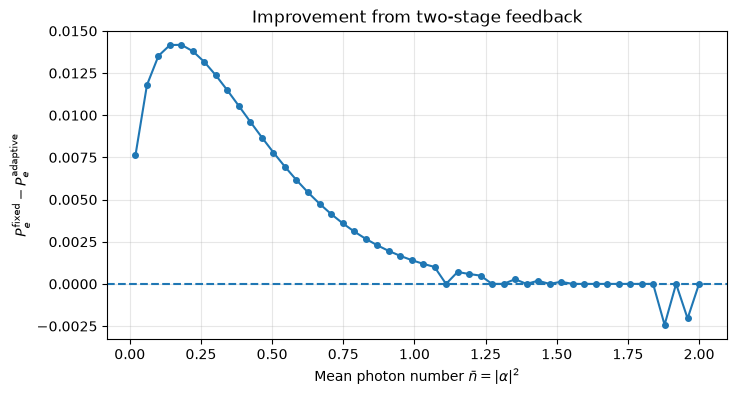

In [14]:
#we can also plot the improvement of the two-stage adaptive receiver over the optimized fixed displacement receiver.
improvement = fixed_errors - adaptive_errors

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    nbar_values,
    improvement,
    marker="o",
    markersize=4
)

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"$P_e^{\mathrm{fixed}} - P_e^{\mathrm{adaptive}}$")
ax.set_title("Improvement from two-stage feedback")

ax.grid(alpha=0.3)
fig.savefig(
    "../figures/two_stage_improvement.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Generalize the adaptive receiver to any number of stages

We now stop hard-coding the two-stage decision tree and build one function that can evaluate an adaptive receiver with any number of stages $M$.

For an $M$-stage binary decision tree, every possible measurement history corresponds to one displacement parameter.

The total number of displacement parameters is

$$
2^M - 1.
$$

For example,

$$
M=2 \Rightarrow 3,
$$

$$
M=3 \Rightarrow 7,
$$

$$
M=4 \Rightarrow 15.
$$

Each displacement corresponds to one node in the decision tree and determines the displacement applied for that particular measurement history.

In [15]:
from itertools import product

In [16]:
#We define a function that computes the index of a node in a binary feedback tree based on the history of click/no-click outcomes.
def history_index(history):
    #Index of a node in a binary feedback tree

    if len(history) == 0:
        return 0

    binary_value = 0

    for bit in history:
        binary_value = 2 * binary_value + int(bit)

    return (2 ** len(history) - 1) + binary_value

In [17]:
#We can then define a function that computes the exact error probability of an adaptive binary receiver tree with a given number of stages and displacement values.
def adaptive_tree_error(nbar, betas, stages):
    #Exact error probability for an adaptive binary receiver tree

    expected_betas = 2 ** stages - 1

    if len(betas) != expected_betas:
        raise ValueError(
            f"{stages} stages require {expected_betas} displacement values."
        )

    alpha_bin = np.sqrt(nbar / stages)

    total_error = 0.0

    # We go through every possible full click/no-click history
    for history in product([False, True], repeat=stages):

        p_plus = 1.0
        p_minus = 1.0

        previous_history = []

        for outcome in history:

            node = history_index(previous_history)
            beta = betas[node]

            p_plus *= detector_outcome_probability(
                +alpha_bin,
                beta,
                outcome
            )

            p_minus *= detector_outcome_probability(
                -alpha_bin,
                beta,
                outcome
            )

            previous_history.append(outcome)

        # and at the end of this history, guess the more likely state
        total_error += min(
            0.5 * p_plus,
            0.5 * p_minus
        )

    return total_error

In [18]:
#We check that the adaptive tree error function gives the same result as the two-stage error function for two stages.
error_general = adaptive_tree_error(
    nbar_test,
    betas,
    stages=2
)

error_old = two_stage_error(
    nbar_test,
    betas[0],
    betas[1],
    betas[2]
)

print("General tree:", error_general)
print("Old two-stage:", error_old)

General tree: 0.1607675372581365
Old two-stage: 0.1607675372581365


In [19]:
#We make a general optimization function for an adaptive receiver with any number of stages using differential evolution.
def optimize_adaptive_tree(nbar, stages, seed=1234):
    n_betas = 2 ** stages - 1

    result = differential_evolution(
        lambda betas: adaptive_tree_error(
            nbar,
            betas,
            stages
        ),
        bounds=[(-3, 3)] * n_betas,
        seed=seed,
        popsize=25,
        maxiter=2000,
        tol=1e-8,
        polish=True
    )

    return result.x, result.fun

In [20]:
#We test the optimization of the adaptive tree for 2 and 3 stages and print the results.
nbar_test = 0.5

betas_2, error_2 = optimize_adaptive_tree(
    nbar_test,
    stages=2
)

betas_3, error_3 = optimize_adaptive_tree(
    nbar_test,
    stages=3
)

print("2-stage error:", error_2)
print("3-stage error:", error_3)
print("Number of 3-stage parameters:", len(betas_3))

2-stage error: 0.04646800182629789
3-stage error: 0.043281833708555116
Number of 3-stage parameters: 7


In [21]:
nbar_test = 0.5
stage_values = [1, 2, 3, 4, 5]

stage_errors = []
stage_betas = []

for stages in stage_values:

    betas, error = optimize_adaptive_tree(
        nbar_test,
        stages=stages
    )

    stage_betas.append(betas)
    stage_errors.append(error)

    print(
        f"{stages} stage(s): "
        f"{len(betas)} parameters, "
        f"error = {error:.6f}"
    )

stage_errors = np.array(stage_errors)

1 stage(s): 1 parameters, error = 0.054361
2 stage(s): 3 parameters, error = 0.046468
3 stage(s): 7 parameters, error = 0.043282
4 stage(s): 15 parameters, error = 0.041548
5 stage(s): 31 parameters, error = 0.040448


In [22]:
helstrom_limit = helstrom_error(nbar_test)

print("Helstrom bound:", helstrom_limit)

Helstrom bound: 0.03506325248390313


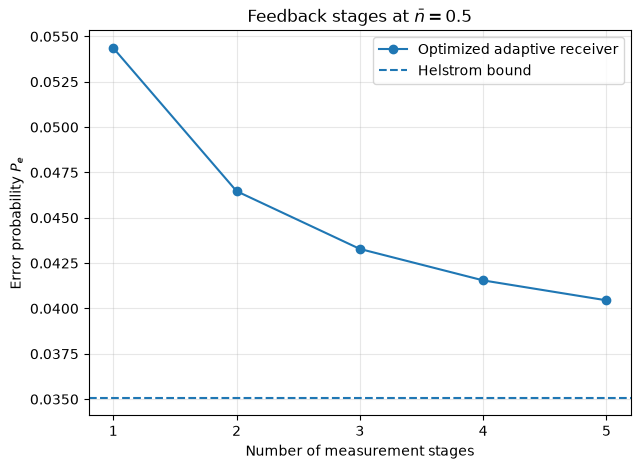

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    stage_values,
    stage_errors,
    marker="o",
    label="Optimized adaptive receiver"
)

ax.axhline(
    helstrom_limit,
    linestyle="--",
    label="Helstrom bound"
)

ax.set_xlabel("Number of measurement stages")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title(
    rf"Feedback stages at $\bar{{n}}={nbar_test}$"
)

ax.set_xticks(stage_values)

ax.grid(alpha=0.3)
ax.legend()
fig.savefig(
    "../figures/Feedback_stages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
stage_numbers = np.array([1, 2, 3, 4, 5])

stage_errors_n05 = np.array([
    0.054361,
    0.046468,
    0.043282,
    0.041548,
    0.040448,
])

np.savez(
    "../data/stage_convergence_n05.npz",
    stages=stage_numbers,
    errors=stage_errors_n05,
)

In [41]:
nbar_values = np.linspace(0.05, 2, 15)
stage_values = [1, 2, 3, 4]

errors_by_stage = {}

for stages in stage_values:

    errors = []

    print(f"\nOptimizing {stages} stage(s)...")

    for i, n in enumerate(nbar_values):

        _, error = optimize_adaptive_tree(
            n,
            stages=stages
        )

        errors.append(error)

        print(
            f"{i + 1}/{len(nbar_values)} "
            f"nbar={n:.2f}, error={error:.5f}"
        )

    errors_by_stage[stages] = np.array(errors)
np.savez(
    "../data/adaptive_stage_sweep.npz",
    nbar_values=nbar_values,
    errors_1=errors_by_stage[1],
    errors_2=errors_by_stage[2],
    errors_3=errors_by_stage[3],
    errors_4=errors_by_stage[4],
)


Optimizing 1 stage(s)...
1/15 nbar=0.05, error=0.31444
2/15 nbar=0.19, error=0.16995
3/15 nbar=0.33, error=0.10091
4/15 nbar=0.47, error=0.06103
5/15 nbar=0.61, error=0.03691
6/15 nbar=0.75, error=0.02217
7/15 nbar=0.89, error=0.01320
8/15 nbar=1.03, error=0.00778
9/15 nbar=1.16, error=0.00455
10/15 nbar=1.30, error=0.00265
11/15 nbar=1.44, error=0.00153
12/15 nbar=1.58, error=0.00088
13/15 nbar=1.72, error=0.00051
14/15 nbar=1.86, error=0.00029
15/15 nbar=2.00, error=0.00017

Optimizing 2 stage(s)...
1/15 nbar=0.05, error=0.30338
2/15 nbar=0.19, error=0.15583
3/15 nbar=0.33, error=0.08911
4/15 nbar=0.47, error=0.05243
5/15 nbar=0.61, error=0.03115
6/15 nbar=0.75, error=0.01856
7/15 nbar=0.89, error=0.01105
8/15 nbar=1.03, error=0.00656
9/15 nbar=1.16, error=0.00388
10/15 nbar=1.30, error=0.00229
11/15 nbar=1.44, error=0.00135
12/15 nbar=1.58, error=0.00088
13/15 nbar=1.72, error=0.00051
14/15 nbar=1.86, error=0.00029
15/15 nbar=2.00, error=0.00016

Optimizing 3 stage(s)...
1/15 nbar=

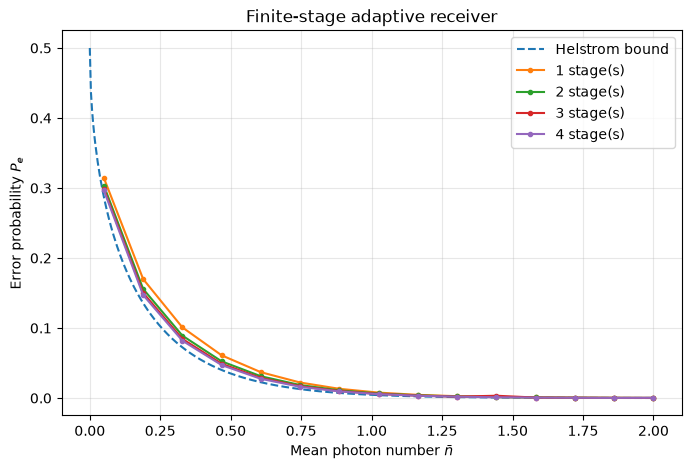

In [25]:
nbar_smooth = np.linspace(0, 2, 500)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nbar_smooth,
    helstrom_error(nbar_smooth),
    linestyle="--",
    label="Helstrom bound"
)

for stages in stage_values:
    ax.plot(
        nbar_values,
        errors_by_stage[stages],
        marker="o",
        markersize=3,
        label=f"{stages} stage(s)"
    )

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Finite-stage adaptive receiver")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

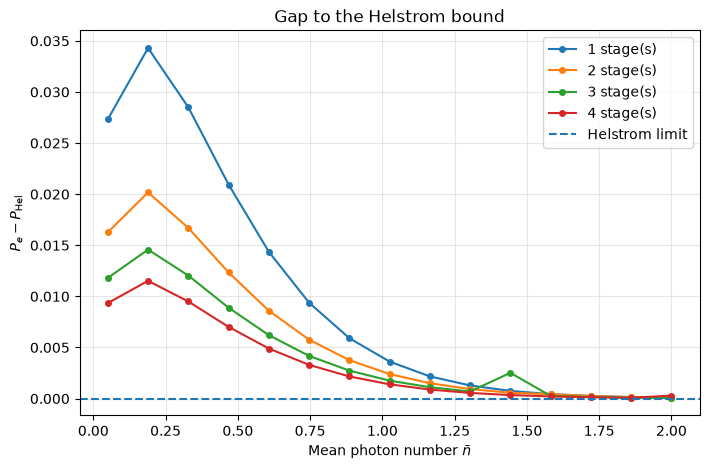

In [26]:
helstrom_values = helstrom_error(nbar_values)

fig, ax = plt.subplots(figsize=(8, 5))

for stages in stage_values:
    gap = errors_by_stage[stages] - helstrom_values

    ax.plot(
        nbar_values,
        gap,
        marker="o",
        markersize=4,
        label=f"{stages} stage(s)"
    )

ax.axhline(0, linestyle="--", label="Helstrom limit")

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"$P_e - P_{\mathrm{Hel}}$")
ax.set_title("Gap to the Helstrom bound")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## Comparing a simple feedback rule with the fully optimized tree

So far, we have allowed every node in the decision tree to have its own independent displacement. This means very slow optimization even at low step counts. Now we test whether a much simpler Dolinar-ish feedback rule can achieve similar performance. 

A natural constrained feedback strategy is:

- We choose one displacement magnitude $b_i$ for each stage,
- start with one displacement sign,
- no click, keep the sign,
- click, flip the sign.

For $M$ stages, we therefore only optimize

$$
b_1,b_2,\ldots,b_M,
$$

instead of

$$
2^M-1
$$

independent displacement parameters.

For example, with $M=4$,

$$
\text{full adaptive tree}: 15 \text{ parameters},
$$

while

$$
\text{sign-flip feedback}: 4 \text{ parameters}.
$$

This gives a useful comparison between the performance of a fully optimized adaptive strategy and a much simpler feedback rule with far fewer parameters.

In [27]:
def sign_flip_error(nbar, magnitudes, stages):
    #Error probability for a sign-flip feedback strategy

    if len(magnitudes) != stages:
        raise ValueError(
            f"{stages} stages require {stages} displacement magnitudes."
        )

    alpha_bin = np.sqrt(nbar / stages)

    total_error = 0.0

    for history in product([False, True], repeat=stages):

        p_plus = 1.0
        p_minus = 1.0

        # Start with positive displacement
        sign = 1

        for i, outcome in enumerate(history):

            beta = sign * magnitudes[i]

            p_plus *= detector_outcome_probability(
                +alpha_bin,
                beta,
                outcome
            )

            p_minus *= detector_outcome_probability(
                -alpha_bin,
                beta,
                outcome
            )

            # Click -> flip displacement sign
            if outcome:
                sign *= -1

        total_error += min(
            0.5 * p_plus,
            0.5 * p_minus
        )

    return total_error

In [28]:
def optimize_sign_flip(nbar, stages, seed=1234):

    result = differential_evolution(
        lambda magnitudes: sign_flip_error(
            nbar,
            magnitudes,
            stages
        ),
        bounds=[(0, 3)] * stages,
        seed=seed,
        polish=True
    )

    return result.x, result.fun

In [29]:
nbar_test = 0.5
stages = 4

magnitudes, sign_flip_err = optimize_sign_flip(
    nbar_test,
    stages
)

_, full_tree_err = optimize_adaptive_tree(
    nbar_test,
    stages
)

print("Optimized magnitudes:", magnitudes)
print("Sign-flip error:", sign_flip_err)
print("Full adaptive error:", full_tree_err)

Optimized magnitudes: [0.73795556 0.47337173 0.41318825 0.38636008]
Sign-flip error: 0.04214042302554493
Full adaptive error: 0.041547724778672614


In [42]:
sign_flip_errors = []

for i, n in enumerate(nbar_values):

    _, error = optimize_sign_flip(
        n,
        stages=4,
        seed=1234
    )

    sign_flip_errors.append(error)

    print(
        f"{i + 1}/{len(nbar_values)} "
        f"nbar={n:.2f}, error={error:.5f}"
    )

sign_flip_errors = np.array(sign_flip_errors)
np.savez(
    "../data/feedback_strategy_sweep.npz",
    nbar_values=nbar_values,
    full_tree_errors=errors_by_stage[4],
    sign_flip_errors=sign_flip_errors,
)

1/15 nbar=0.05, error=0.29768
2/15 nbar=0.19, error=0.14854
3/15 nbar=0.33, error=0.08292
4/15 nbar=0.47, error=0.04776
5/15 nbar=0.61, error=0.02785
6/15 nbar=0.75, error=0.01633
7/15 nbar=0.89, error=0.00959
8/15 nbar=1.03, error=0.00563
9/15 nbar=1.16, error=0.00331
10/15 nbar=1.30, error=0.00194
11/15 nbar=1.44, error=0.00114
12/15 nbar=1.58, error=0.00066
13/15 nbar=1.72, error=0.00039
14/15 nbar=1.86, error=0.00023
15/15 nbar=2.00, error=0.00013


In [34]:
full_tree_errors = errors_by_stage[4]

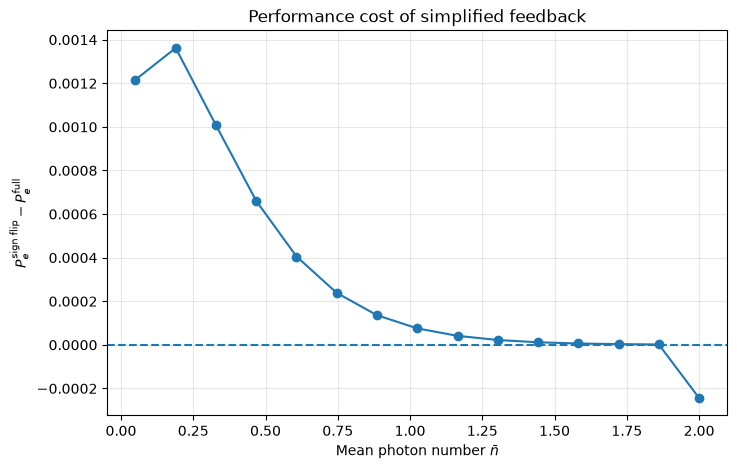

In [35]:
feedback_penalty = sign_flip_errors - full_tree_errors

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nbar_values,
    feedback_penalty,
    marker="o"
)

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(
    r"$P_e^{\mathrm{sign\ flip}} - P_e^{\mathrm{full}}$"
)
ax.set_title("Performance cost of simplified feedback")

ax.grid(alpha=0.3)

plt.show()

In [ ]:
def detector_outcome_probability_imperfect(
    signal,
    beta,
    clicked,
    eta=1.0,
    dark_count=0.0
):
   #Click/no-click probability with detector inefficiency and dark counts

    displaced_amplitude = signal + beta

    mean_detected_photons = eta * np.abs(displaced_amplitude) ** 2

    p_no_click = np.exp(
        -mean_detected_photons - dark_count
    )

    if clicked:
        return 1 - p_no_click

    return p_no_click

In [39]:
def adaptive_tree_error_imperfect(
    nbar,
    betas,
    stages,
    eta=1.0,
    dark_count=0.0
):
    #Adaptive receiver error with detector imperfections

    expected_betas = 2 ** stages - 1

    if len(betas) != expected_betas:
        raise ValueError(
            f"{stages} stages require {expected_betas} displacement values."
        )

    alpha_bin = np.sqrt(nbar / stages)

    total_error = 0.0

    for history in product([False, True], repeat=stages):

        p_plus = 1.0
        p_minus = 1.0

        previous_history = []

        for outcome in history:

            node = history_index(previous_history)
            beta = betas[node]

            p_plus *= detector_outcome_probability_imperfect(
                +alpha_bin,
                beta,
                outcome,
                eta,
                dark_count
            )

            p_minus *= detector_outcome_probability_imperfect(
                -alpha_bin,
                beta,
                outcome,
                eta,
                dark_count
            )

            previous_history.append(outcome)

        total_error += min(
            0.5 * p_plus,
            0.5 * p_minus
        )

    return total_error

In [40]:
nbar_test = 0.5
stages = 4

betas_ideal, error_ideal = optimize_adaptive_tree(
    nbar_test,
    stages
)

print(
    "Ideal detector:",
    adaptive_tree_error_imperfect(
        nbar_test,
        betas_ideal,
        stages,
        eta=1.0,
        dark_count=0.0
    )
)

print(
    "80% efficient detector:",
    adaptive_tree_error_imperfect(
        nbar_test,
        betas_ideal,
        stages,
        eta=0.8,
        dark_count=0.0
    )
)

print(
    "80% efficient + dark counts:",
    adaptive_tree_error_imperfect(
        nbar_test,
        betas_ideal,
        stages,
        eta=0.8,
        dark_count=0.01
    )
)

Ideal detector: 0.041547724778672614
80% efficient detector: 0.06297839460613476
80% efficient + dark counts: 0.07908510829775732
